In [297]:
from ipywidgets import fixed, interact
import matplotlib.pyplot as plt
import numpy as np
import torch
from typing import Dict

from hyperspace.backends import HRRBackend
from hyperspace.core import (
    CleanupModule,
    MemoryStorageModule,
    PositionalEncoderModule,
    PositionalInversionModule,
    RegressionModule,
    ValueEncoderModule
)

In [298]:
EXP_CONFIG: Dict = {
    "num_training_points": 20,
    "num_gt_points": 100,
    "seed": 101,
    "x_dim_min": 0,
    "x_dim_max": 2 * np.pi,
}

VSA_CONFIG: Dict = {
    "vector_dim": 256,
    "vector_length_scale": 0.5,
    "device": "cpu"
}

In [299]:
# -----------------
# Generate GT Data
# -----------------
x_gt: np.ndarray = np.linspace(
    EXP_CONFIG["x_dim_min"],
    EXP_CONFIG["x_dim_max"],
    EXP_CONFIG["num_gt_points"]
)
y_gt: np.ndarray = np.sin(x_gt)

# normalize both axes to between [0, 1]
x_gt_norm = x_gt / EXP_CONFIG["x_dim_max"]
y_gt_norm = y_gt + 1
y_gt_norm /= 2

# updating types and shapes to conform to hyperspace's API

x_gt_norm: torch.Tensor = torch.from_numpy(x_gt_norm)
y_gt_norm: torch.Tensor = torch.from_numpy(y_gt_norm)

x_gt_norm = x_gt_norm.unsqueeze(-1)
y_gt_norm = y_gt_norm.unsqueeze(-1)

print(f"x_gt_norm type: {type(x_gt_norm)}; shape: {x_gt_norm.shape}")
print(f"y_gt_norm type: {type(y_gt_norm)}; shape: {y_gt_norm.shape}")

assert isinstance(x_gt_norm, torch.Tensor)
assert isinstance(y_gt_norm, torch.Tensor)
assert x_gt_norm.shape == (EXP_CONFIG["num_gt_points"], 1)
assert y_gt_norm.shape == (EXP_CONFIG["num_gt_points"], 1)

x_gt_norm type: <class 'torch.Tensor'>; shape: torch.Size([100, 1])
y_gt_norm type: <class 'torch.Tensor'>; shape: torch.Size([100, 1])


In [300]:
# ----------------------
# Generate Sampled Data
# ----------------------
x_Train: np.ndarray = np.linspace(
    EXP_CONFIG["x_dim_min"],
    EXP_CONFIG["x_dim_max"],
    EXP_CONFIG["num_training_points"]
)
y_Train: np.ndarray = np.sin(x_Train)

# normalize both axes to between [0, 1]
x_Train_norm: np.ndarray = x_Train / EXP_CONFIG["x_dim_max"]
y_Train_norm: np.ndarray = y_Train + 1
y_Train_norm /= 2

assert isinstance(x_Train_norm, np.ndarray)
assert isinstance(y_Train_norm, np.ndarray)
assert x_Train_norm.shape == (EXP_CONFIG["num_training_points"],)
assert y_Train_norm.shape == (EXP_CONFIG["num_training_points"],)

# updating types and shapes to conform to hyperspace's API

x_Train_norm: torch.Tensor = torch.from_numpy(x_Train_norm)
y_Train_norm: torch.Tensor = torch.from_numpy(y_Train_norm)

x_Train_norm = x_Train_norm.unsqueeze(-1)
y_Train_norm = y_Train_norm.unsqueeze(-1)

print(f"x_Train_norm type: {type(x_Train_norm)}; shape: {x_Train_norm.shape}")
print(f"y_Train_norm type: {type(y_Train_norm)}; shape: {y_Train_norm.shape}")

assert isinstance(x_Train_norm, torch.Tensor)
assert isinstance(y_Train_norm, torch.Tensor)
assert x_Train_norm.shape == (EXP_CONFIG["num_training_points"], 1)
assert y_Train_norm.shape == (EXP_CONFIG["num_training_points"], 1)

x_Train_norm type: <class 'torch.Tensor'>; shape: torch.Size([20, 1])
y_Train_norm type: <class 'torch.Tensor'>; shape: torch.Size([20, 1])


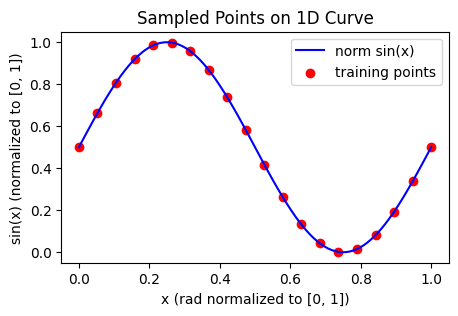

In [301]:
plt.figure(figsize=(5, 3))
plt.plot(x_gt_norm, y_gt_norm, label="norm sin(x)", color="blue")
plt.scatter(x_Train_norm, y_Train_norm, label="training points", color="red")
plt.title("Sampled Points on 1D Curve")
plt.xlabel("x (rad normalized to [0, 1])")
plt.ylabel("sin(x) (normalized to [0, 1])")
plt.legend()
plt.show()

In [302]:
# ----------------------------------------------------------------
# Adding offest to avoid identity problem with fractional binding
# ----------------------------------------------------------------
x_gt_norm += 1
x_Train_norm += 1
y_gt_norm += 1
y_Train_norm += 1

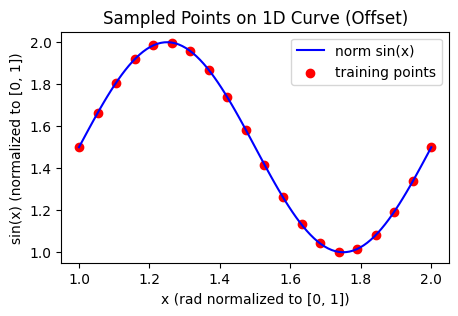

In [303]:
plt.figure(figsize=(5, 3))
plt.plot(x_gt_norm, y_gt_norm, label="norm sin(x)", color="blue")
plt.scatter(x_Train_norm, y_Train_norm, label="training points", color="red")
plt.title("Sampled Points on 1D Curve (Offset)")
plt.xlabel("x (rad normalized to [0, 1])")
plt.ylabel("sin(x) (normalized to [0, 1])")
plt.legend()
plt.show()

In [304]:
# ------------------------------
# Initialize HyperSpace Modules
# ------------------------------
hrr_backend = HRRBackend(
    vector_dim=VSA_CONFIG["vector_dim"],
    length_scale=VSA_CONFIG["vector_length_scale"],
    device=VSA_CONFIG["device"],
    seed=EXP_CONFIG["seed"]
)

In [305]:
# -----------------------------------------------------------------
# Encode the ground truth and sampling positions into vector space
# -----------------------------------------------------------------
x_gt_vectors, _ = hrr_backend.positional_encoding(x_gt_norm)
x_Train_vectors, _ = hrr_backend.positional_encoding(x_Train_norm)

x_gt_vectors, _ = hrr_backend.normalize(x_gt_vectors)
x_Train_vectors, _ = hrr_backend.normalize(x_Train_vectors)

print(f"x_gt_vectors type: {type(x_gt_vectors)}; shape: {x_gt_vectors.shape}")
print(f"x_Train_vectors type: {type(x_Train_vectors)}; shape: {x_Train_vectors.shape}")

assert isinstance(x_gt_vectors, torch.Tensor)
assert isinstance(x_Train_vectors, torch.Tensor)
assert x_gt_vectors.shape == (
    EXP_CONFIG["num_gt_points"],
    VSA_CONFIG["vector_dim"]
)
assert x_Train_vectors.shape == (
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"]
)

x_gt_vectors type: <class 'torch.Tensor'>; shape: torch.Size([100, 256])
x_Train_vectors type: <class 'torch.Tensor'>; shape: torch.Size([20, 256])


X Sims Min: -0.2084293744994788; Max: 1.0000000000000002


Text(0, 0.5, 'Sample Idx')

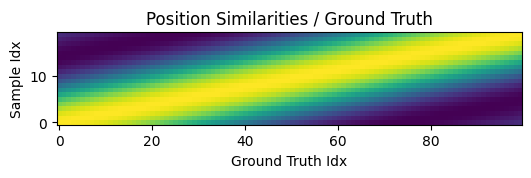

In [306]:
x_sims, _ = hrr_backend.similarity(x_gt_vectors, x_Train_vectors)

print(f"X Sims Min: {torch.min(x_sims)}; Max: {torch.max(x_sims)}")

plt.figure(figsize=(6, 2))
plt.imshow(x_sims.T, origin="lower")
plt.title("Position Similarities / Ground Truth")
plt.xlabel("Ground Truth Idx")
plt.ylabel("Sample Idx")

In [307]:
# -----------------------------------------------------------------
# Encode the ground truth and sampling values into vector space
# -----------------------------------------------------------------
y_gt_vectors, _ = hrr_backend.value_encoding(y_gt_norm)
y_Train_vectors, _ = hrr_backend.value_encoding(y_Train_norm)

y_gt_vectors, _ = hrr_backend.normalize(y_gt_vectors)
y_Train_vectors, _ = hrr_backend.normalize(y_Train_vectors)

print(f"y_gt_vectors type: {type(y_gt_vectors)}; shape: {y_gt_vectors.shape}")
print(f"y_Train_vectors type: {type(y_Train_vectors)}; shape: {y_Train_vectors.shape}")

assert isinstance(y_gt_vectors, torch.Tensor)
assert isinstance(y_Train_vectors, torch.Tensor)
assert y_gt_vectors.shape == (
    EXP_CONFIG["num_gt_points"],
    VSA_CONFIG["vector_dim"]
)
assert y_Train_vectors.shape == (
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"]
)

y_gt_vectors type: <class 'torch.Tensor'>; shape: torch.Size([100, 256])
y_Train_vectors type: <class 'torch.Tensor'>; shape: torch.Size([20, 256])


Y Sims Min: -0.18637811067587431; Max: 1.0


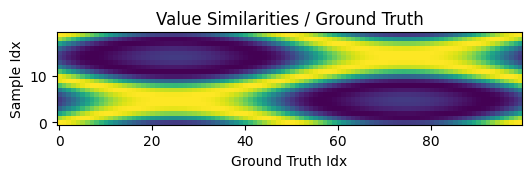

In [308]:
y_sims, _ = hrr_backend.similarity(y_gt_vectors, y_Train_vectors)

print(f"Y Sims Min: {torch.min(y_sims)}; Max: {torch.max(y_sims)}")

plt.figure(figsize=(6, 2))
plt.imshow(y_sims.T, origin="lower")
plt.title("Value Similarities / Ground Truth")
plt.xlabel("Ground Truth Idx")
plt.ylabel("Sample Idx")

del y_sims

In [309]:
# ------------------------------
# Initialize HyperSpace Modules
# ------------------------------
cleanup_module = CleanupModule(
    backend=hrr_backend,
    values=y_gt_norm
)
memory_storage_module = MemoryStorageModule(
    backend=hrr_backend
)
positional_encoder_module = PositionalEncoderModule(
    backend=hrr_backend,
)
positional_inversion_module = PositionalInversionModule(
    backend=hrr_backend,
    positions=x_Train_norm
)
codebook, _ = hrr_backend.value_encoding(y_gt_norm)
regression_module = RegressionModule(
    backend=hrr_backend,
    codebook=codebook,
    values=y_gt_norm
)
value_encoder_module = ValueEncoderModule(
    backend=hrr_backend
)

In [310]:
# ------------------------------------------------------------
# Evaluate the similarities binded position and value vectors
# with respect to the gt position and value vectors
# ------------------------------------------------------------
sampled_pv_matrix = torch.zeros(( # sampled positions, sampled values, vector_dim
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"]
))
sampled_vs_versus_positions = torch.zeros(( # sampled positions, sampled values, gt_positions
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_gt_points"]    
))
sampled_vs_versus_values = torch.zeros(( # sampled positions, sampled values, gt_values
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_gt_points"]    
))

# Bind all positions and values together
for p_i in range(EXP_CONFIG["num_training_points"]):
    for v_i in range(EXP_CONFIG["num_training_points"]):
        
        pv = x_Train_vectors[p_i]
        vv = y_Train_vectors[v_i]
        pvv, _ = hrr_backend.bind(vv, pv)
        sampled_pv_matrix[p_i, v_i] = pvv

# Compute similarities with all gt positions
for p_i in range(EXP_CONFIG["num_training_points"]):
    for v_i in range(EXP_CONFIG["num_training_points"]):
        for gt_i in range(EXP_CONFIG["num_gt_points"]):
            pv = sampled_pv_matrix[p_i, v_i]
            gt_v = x_gt_vectors[gt_i]
            s, _ = hrr_backend.similarity(pv, gt_v)
            sampled_vs_versus_positions[p_i, v_i, gt_i] = s

# Compute similarities with all gt values
for p_i in range(EXP_CONFIG["num_training_points"]):
    for v_i in range(EXP_CONFIG["num_training_points"]):
        for gt_i in range(EXP_CONFIG["num_gt_points"]):
            pv = sampled_pv_matrix[p_i, v_i]
            gt_v = y_gt_vectors[gt_i]
            s, _ = hrr_backend.similarity(pv, gt_v)
            sampled_vs_versus_values[p_i, v_i, gt_i] = s

print(f"Value Sims Min: {torch.min(sampled_vs_versus_values)}; Max: {torch.max(sampled_vs_versus_values)}")
print(f"Position Sims Min: {torch.min(sampled_vs_versus_positions)}; Max: {torch.max(sampled_vs_versus_positions)}")

Value Sims Min: -0.10108407586812973; Max: 0.15310680866241455
Position Sims Min: -0.15495607256889343; Max: 0.12855535745620728


In [311]:
def plot_slice(slice_index, m, t):
    plt.clf()
    plt.title(t)
    plt.imshow(m[:, :, slice_index], vmin=0.0, vmax=1.0)
    plt.xlabel("Value Index")
    plt.ylabel("Position Index")
    plt.show()

def plot_interactive_slice(m, t):
    interact(
        plot_slice,
        slice_index=(0, m.shape[-1] - 1),
        m=fixed(m),
        t=fixed(t)
    )

In [312]:
plot_interactive_slice(sampled_vs_versus_positions, "PV Vectors / Positions")

interactive(children=(IntSlider(value=49, description='slice_index', max=99), Output()), _dom_classes=('widget…

In [313]:
plot_interactive_slice(sampled_vs_versus_values, "PV Vectors / Values")

interactive(children=(IntSlider(value=49, description='slice_index', max=99), Output()), _dom_classes=('widget…

In [314]:
del (
    sampled_pv_matrix,
    sampled_vs_versus_positions,
    sampled_vs_versus_values
)

In [315]:
# -------------------------------------------------------------------
# Experimenting with < 1 FPE producing identity vectors when binding
# -------------------------------------------------------------------

p, _ = hrr_backend.positional_encoding(torch.tensor([1]))
v, _ = hrr_backend.value_encoding(torch.tensor([1]))


pv, _ = hrr_backend.bind(p, v)

print(f"SIM(p, v)       : {hrr_backend.similarity(p, v)[0]}")
print(f"SIM(p, p bind v): {hrr_backend.similarity(p, pv)[0]}")
print(f"SIM(v, p bind v): {hrr_backend.similarity(v, pv)[0]}")

p, _ = hrr_backend.positional_encoding(torch.tensor([1]))
v, _ = hrr_backend.value_encoding(torch.tensor([1]))

print(f"\n Encoding < 1:")

p, _ = hrr_backend.positional_encoding(torch.tensor([0.1]))
v, _ = hrr_backend.value_encoding(torch.tensor([1]))

pv, _ = hrr_backend.bind(p, v)

print(f"SIM(p, v)       : {hrr_backend.similarity(p, v)[0]}")
print(f"SIM(p, p bind v): {hrr_backend.similarity(p, pv)[0]}")
print(f"SIM(v, p bind v): {hrr_backend.similarity(v, pv)[0]}")

print(f"\n Encoding > 1:")

p, _ = hrr_backend.positional_encoding(torch.tensor([10]))
v, _ = hrr_backend.value_encoding(torch.tensor([1]))

pv, _ = hrr_backend.bind(p, v)

print(f"SIM(p, v)       : {hrr_backend.similarity(p, v)[0]}")
print(f"SIM(p, p bind v): {hrr_backend.similarity(p, pv)[0]}")
print(f"SIM(v, p bind v): {hrr_backend.similarity(v, pv)[0]}")

del p, v, pv

SIM(p, v)       : -0.07077590376138687
SIM(p, p bind v): 0.020866859704256058
SIM(v, p bind v): -0.05466818809509277

 Encoding < 1:
SIM(p, v)       : 0.049016475677490234
SIM(p, p bind v): 0.02086685597896576
SIM(v, p bind v): 0.9415216445922852

 Encoding > 1:
SIM(p, v)       : 0.06154641509056091
SIM(p, p bind v): 0.02086677774786949
SIM(v, p bind v): -0.10203160345554352


In [316]:
# --------------------------------------------------------------------------------
# Now that we have validated the individual value and positional encoding module,
# we will leverage the HyperSpace modules to simplify this process for us
# --------------------------------------------------------------------------------
positional_encodings, _ = positional_encoder_module(x_Train_norm)
value_encodings, _ = value_encoder_module(y_Train_norm)
memory, _ = memory_storage_module(
    p_vectors=positional_encodings,
    v_vectors=value_encodings
)

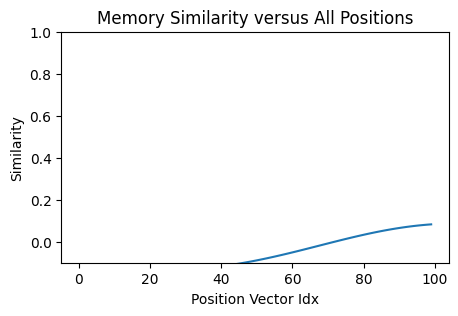

In [317]:
# ---------------------------------------------------------------------
# compare the memory with respect to all ground truth position vectors
# ---------------------------------------------------------------------
m_to_pv_sims, _ = hrr_backend.similarity(memory, x_gt_vectors)

x = torch.arange(0, m_to_pv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(5, 3))
plt.plot(x, m_to_pv_sims)
plt.xlabel("Position Vector Idx")
plt.ylabel("Similarity")
plt.ylim(-0.1, 1)
plt.title("Memory Similarity versus All Positions")

del x, m_to_pv_sims

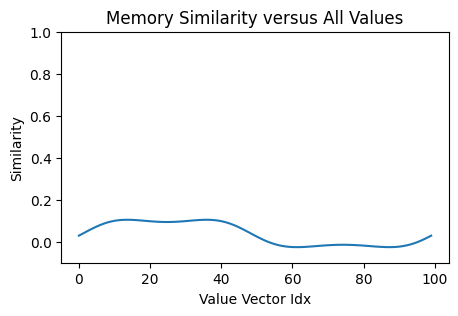

In [318]:
# ---------------------------------------------------------------------
# compare the memory with respect to all ground truth value vectors
# ---------------------------------------------------------------------

m_to_vv_sims, _ = hrr_backend.similarity(memory, y_gt_vectors)

x = torch.arange(0, m_to_vv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(5, 3))
plt.plot(x, m_to_vv_sims)
plt.xlabel("Value Vector Idx")
plt.ylabel("Similarity")
plt.ylim(-0.1, 1)
plt.title("Memory Similarity versus All Values")

del x, m_to_vv_sims

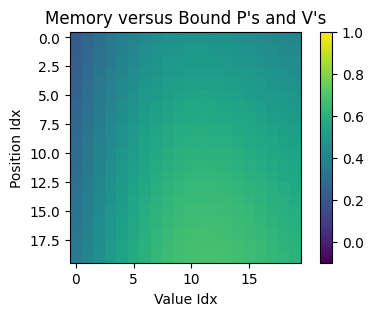

In [319]:
# ----------------------------------------------------------------------------------
# compare the memory with respect to all possible binded position and value vectors
# ----------------------------------------------------------------------------------
pv_sims = torch.zeros((
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
))
for pv_idx in range(EXP_CONFIG["num_training_points"]):
    for vv_idx in range(EXP_CONFIG["num_training_points"]):
        bpv, _ = hrr_backend.bind(
            a=x_gt_vectors[pv_idx],
            b=y_gt_vectors[vv_idx]
        )
        s, _ = hrr_backend.similarity(memory, bpv)
        pv_sims[pv_idx, vv_idx] = s

plt.figure(figsize=(5,3))
plt.imshow(pv_sims, vmin=-0.1, vmax=1.0)
plt.ylabel("Position Idx")
plt.xlabel("Value Idx")
plt.title("Memory versus Bound P's and V's")
plt.colorbar()
plt.show()

del pv_sims

In [320]:
# -----------------------------------------------------------------
# Unbind the memory with all desired positions to hopefully return
# higher quality position-wise value vectors
# -----------------------------------------------------------------
pi_memory, pi_info = positional_inversion_module(memory)

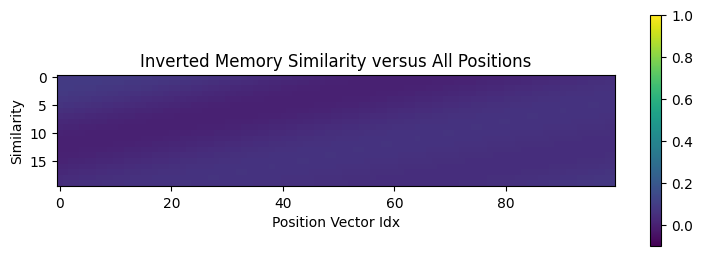

In [321]:
# ---------------------------------------------------------------------
# compare the inverted memory with respect to all
# ground truth position vectors
# ---------------------------------------------------------------------
m_to_pv_sims, _ = hrr_backend.similarity(pi_memory, x_gt_vectors)

x = torch.arange(0, m_to_pv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(9, 3))
plt.imshow(m_to_pv_sims, vmin=-0.1, vmax=1.0)
plt.xlabel("Position Vector Idx")
plt.ylabel("Similarity")
plt.colorbar()
plt.title("Inverted Memory Similarity versus All Positions")

del x, m_to_pv_sims

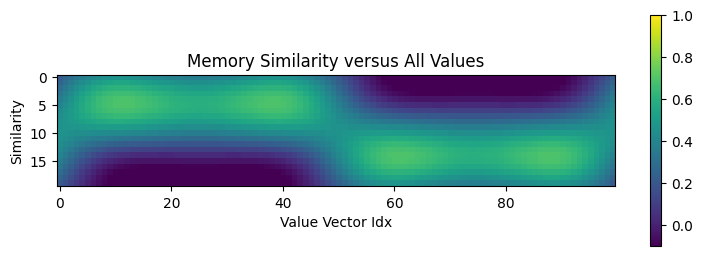

In [322]:
# ---------------------------------------------------------------------
# compare the inverted memory with respect to all
# ground truth value vectors
# ---------------------------------------------------------------------

m_to_vv_sims, _ = hrr_backend.similarity(pi_memory, y_gt_vectors)

x = torch.arange(0, m_to_vv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(9, 3))
plt.imshow(m_to_vv_sims, vmin=-0.1, vmax=1.0)
plt.xlabel("Value Vector Idx")
plt.ylabel("Similarity")
plt.colorbar()
plt.title("Memory Similarity versus All Values")

del x, m_to_vv_sims